# DLBDSMLUSL01 — Machine Learning: Unsupervised Learning and Feature Engineering

## *Case Study Task 1: Mental Health in Technology-related Jobs*

---

### Introduction
The module below implements an **unsupervised machine learning pipeline** for categorizing *technology-oriented employees* according to their answers and to provide visualizations supporting the interpretation of these clusters for planning a **proactive program** to identify, reduce, and prevent mental health issues among technology-oriented employees.

---

### Pipeline Overview
This module covers the complete ML pipeline:

**Data Loading** → **Visualization (Pre)** → **Feature Reduction And Data Pre-Processing** → **Imputation** → **Encoding** → **Standardization** → **Dimensionality Reduction (PCA)** → **Clustering (K-Means)** → **Cluster Profiling and Visualization (Post)**

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
import numpy as np
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer


### Step 1 - Loading the data

In [2]:
# STEP 1 -  Load the data
df = pd.read_csv(r"Data/mental-heath-in-tech-2016_20161114.csv") 
print(f"Data shape before any processing:", df.shape)  


Data shape before any processing: (1433, 63)


### Step 2 — Visualization & Exploratory Data Analysis

### Visualizing the first 10 rows of the raw dataset

In [3]:

pd.set_option('display.max_columns', None)
df.head(10)

,Are you self-employed?,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Do you have medical coverage (private insurance or state-provided) which includes treatment of mental health issues?,Do you know local or online resources to seek help for a mental health disorder?,"If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to clients or business contacts?","If you have revealed a mental health issue to a client or business contact, do you believe this has impacted you negatively?","If you have been diagnosed or treated for a mental health disorder, do you ever reveal this to coworkers or employees?","If you have revealed a mental health issue to a coworker or employee, do you believe this has impacted you negatively?",Do you believe your productivity is ever affected by a mental health issue?,"If yes, what percentage of your work time (time performing primary or secondary job functions) is affected by a mental health issue?",Do you have previous employers?,Have your previous employers provided mental health benefits?,Were you aware of the options for mental health care provided by your previous employers?,Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?,Did your previous employers provide resources to learn more about mental health issues and how to seek help?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Do you think that discussing a physical health issue with previous employers would have negative consequences?,Would you have been willing to discuss a mental health issue with your previous co-workers?,Would you have been willing to discuss a mental health issue with your direct supervisor(s)?,Did you feel that your previous employers took mental health as seriously as physical health?,Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Why or why not?,Would you bring up a mental health issue with a potential employer in an interview?,Why or why not?.1,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a menta

### Analysis of the Missing Values and Cut-off Thresold

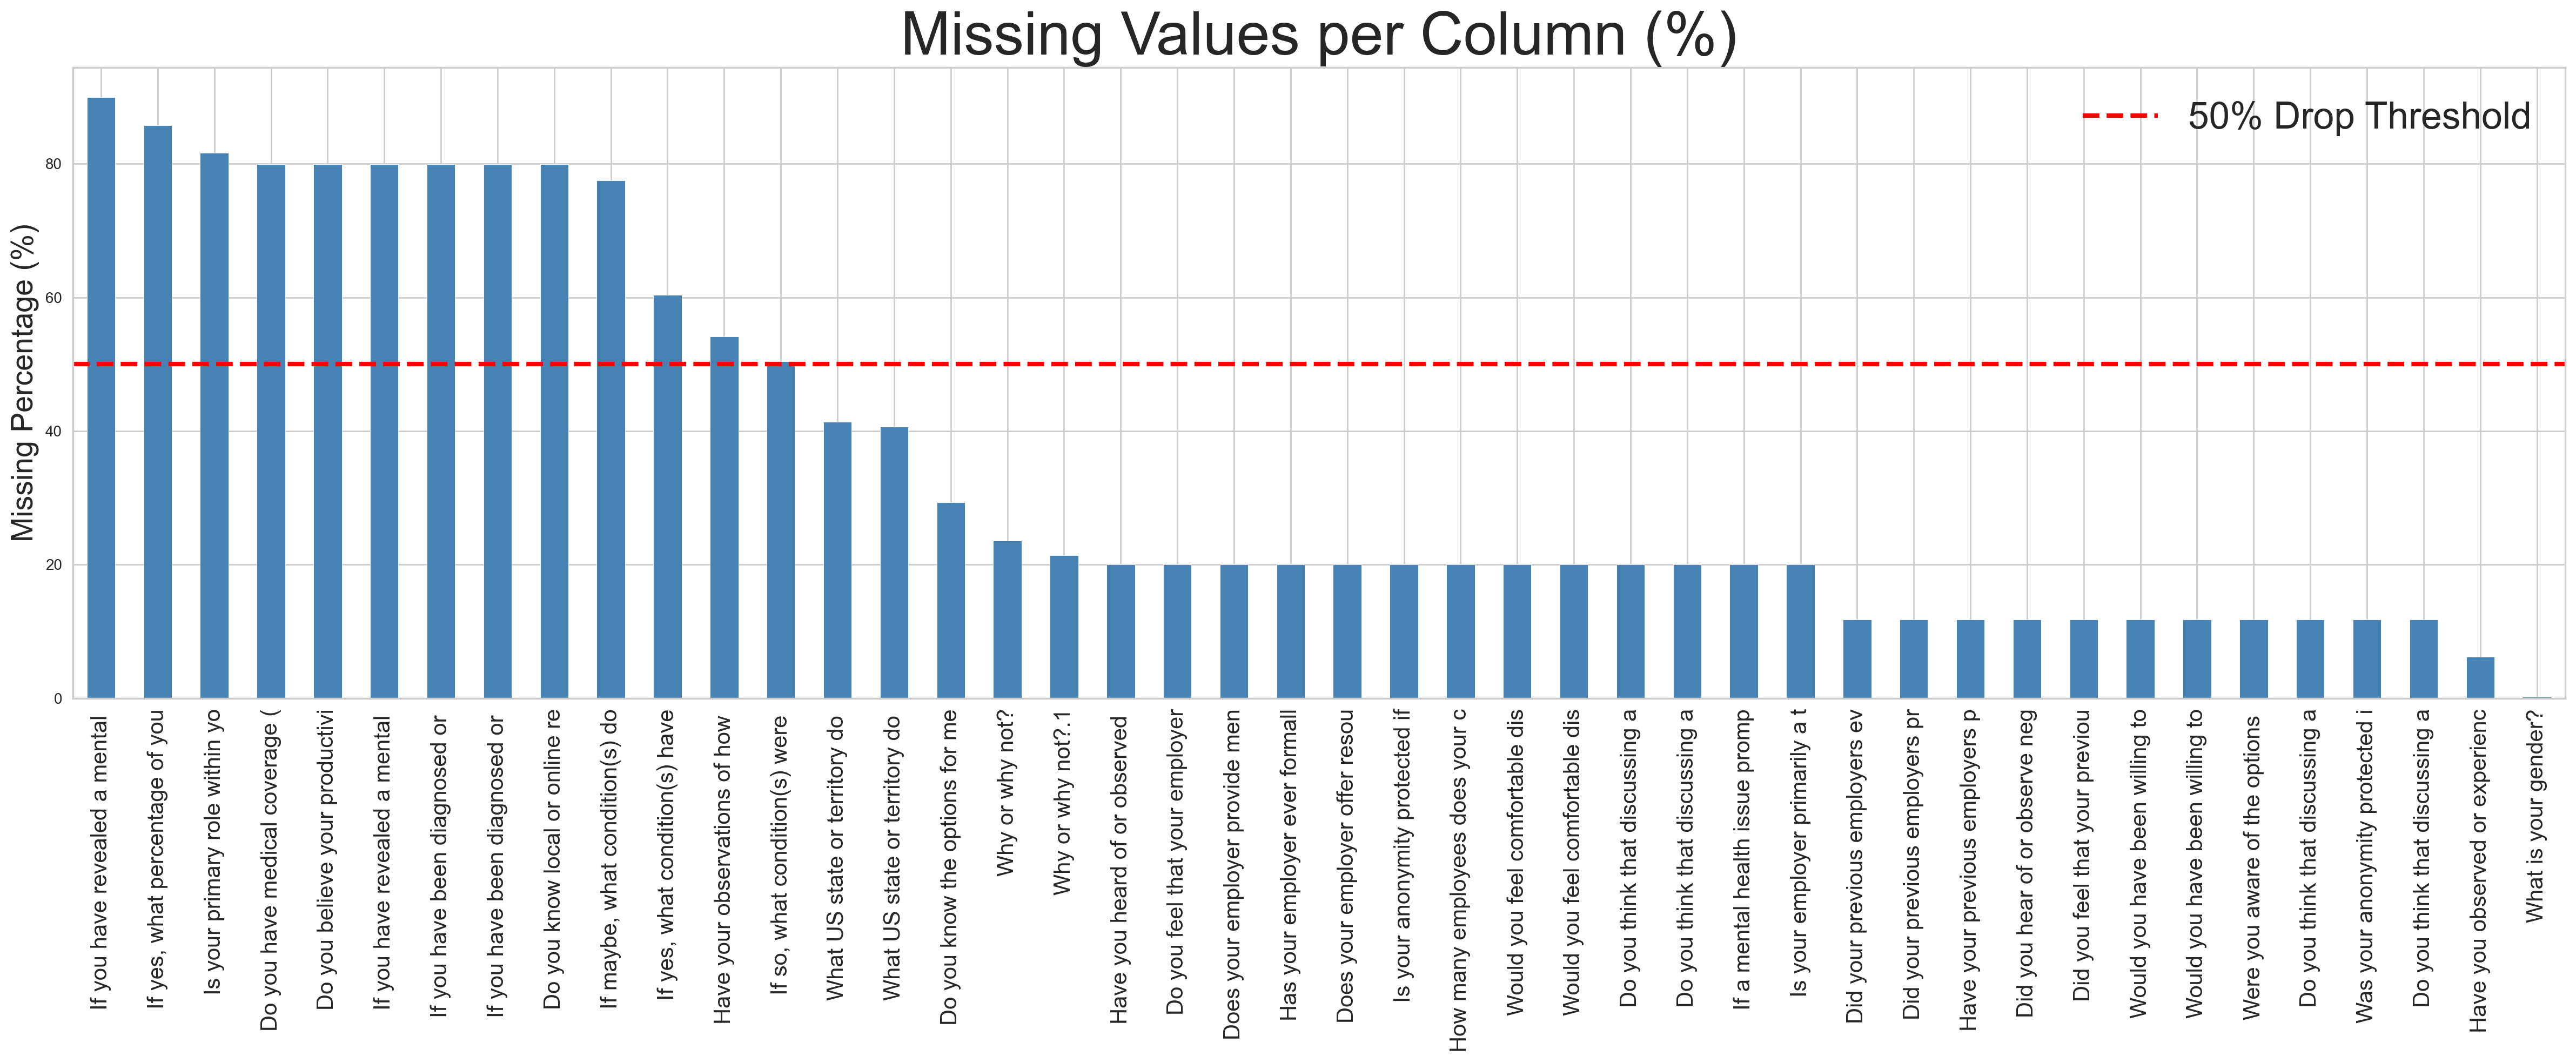

In [4]:
# Dividing the number of missing data items for every column with the total number of rows
# to get the missing data ratio and then multiplying with 100 to get the percentage
missing_percent = (df.isnull().sum() / len(df)) * 100 
missing_percent = missing_percent[missing_percent > 0] #filtering out the columns that don't have any missing values
missing_percent = missing_percent.sort_values(ascending=False) # sorting the columns in descending order in terms of
                                                               # the total number of missing value (left to right)

# Shorten column names for display only (first 30 chars) as it would be very difficult 
# to visualize in the chart
missing_percent.index = [col[:30] for col in missing_percent.index]

#Creating a bar chart with height of each bar = missing percentage
plt.figure(figsize=(24, 10), dpi=200)
missing_percent.plot(kind='bar', color='steelblue', edgecolor='white')
plt.ylabel('Missing Percentage (%)', fontsize=20)

#creating a horizontal line at 50% which is the dropout thresold for our model 
plt.axhline(y=50, color='red', linestyle='--', linewidth=3, label='50% Drop Threshold')
plt.legend(fontsize=25)                                #creating a legend on the top right with the label '50% Drop Threshold'
plt.title('Missing Values per Column (%)', fontsize=40)   #title of the graph
plt.xticks(rotation=90, fontsize=15)          #displaying the x axis columns vertically
plt.subplots_adjust(bottom=0.4)
plt.tight_layout()
plt.savefig('missing_values.png', dpi=200)   #saving the chart in the current directory
plt.show()                                   # displaying the graph


### STEP 3 - Reduction of the features whose missing percentage is more than 50% based on the previous step

In [5]:
#Step 3
delete_columns = []
for col in df.columns:
    if (df[col].isnull().sum() / len(df)) * 100 > 50:
        delete_columns.append(col)
df_reduced = df.drop(columns=delete_columns)
print("Shape of the data now : ", df_reduced.shape)

Shape of the data now :  (1433, 50)


### STEP 4 - Deletion of the Non-Informative open ended question

In [6]:
#STEP 4 - Deletion of the non-informative open ended question

#Looking at the fresh column name after the dropping from the previous step
#for i, col in enumerate(df.columns):
    #print(f"{i}: {col}")   - For reviewing all the columns name for further feature reduction

#Manual dropping of the non-informative columns
manual_drop = [
    # Open ended question which cannot be encoded directly
    'Why or why not?',           
    'Why or why not?.1',         

    # Previous employer block - it doesn't play crucial role and the data of the current employes are more useful
    'Do you have previous employers?',
    'Have your previous employers provided mental health benefits?',
    'Were you aware of the options for mental health care provided by your previous employers?',
    'Did your previous employers ever formally discuss mental health (as part of a wellness campaign or other official communication)?',
    'Did your previous employers provide resources to learn more about mental health issues and how to seek help?',
    'Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?',
    'Do you think that discussing a mental health disorder with previous employers would have negative consequences?',
    'Do you think that discussing a physical health issue with previous employers would have negative consequences?',
    'Would you have been willing to discuss a mental health issue with your previous co-workers?',
    'Would you have been willing to discuss a mental health issue with your direct supervisor(s)?',
    'Did you feel that your previous employers took mental health as seriously as physical health?',
    'Did you hear of or observe negative consequences for co-workers with mental health issues in your previous workplaces?',

    # Removing extra geographic features as the current work country matters more
    'What country do you live in?',               #redundant with work country
    'What US state or territory do you live in?', # too sparse
    'What US state or territory do you work in?', # too sparse
]

#dropping the columns
df_reduced = df_reduced.drop(columns=manual_drop)

# Removing self-employed respondents as its not required
df_reduced = df_reduced[df_reduced['Are you self-employed?'] == 0] 


#Now removing the whole 'Are you self-employed?' columns as it have only one value left which does not makes sense
df_reduced = df_reduced.drop(columns = ['Are you self-employed?'])

#Viewing the data shape
print("After dropping open ended question" \
", previous employs columns and extra geographic features :", df_reduced.shape) #Checking the data shape

After dropping open ended question, previous employs columns and extra geographic features : (1146, 32)


### Step 5 - Data Preprocessing

In [7]:
#Step 5 - Data Preprocessing
# It is the very crucial step as it removes the extra noise in the data which ensures the
#the quality of the data and the model 

# Precautionary Step - 
# Opening the CSV in Excel sometimes causes auto-formatting corruption in the company size column
# The excel converts texts like 6-25 to 25 - Jun, etc. which we don't want.
# And it happens when we open the CSV in Excel to view and save it or (Auto-save).
#We need to fix this first before imputing otherwise it is an unwanted noise as a precaution.

df_preprocessed = df_reduced.copy() # Working copy for preprocessing

# List of all month abbreviations that Excel uses when corrupting date values
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# List of all possible day numbers as strings (1 to 31)
days = [str(i) for i in range(1, 32)]

# Dictionary to convert month name back to its number
month_to_num = {
    'Jan': '1', 'Feb': '2', 'Mar': '3', 'Apr': '4',
    'May': '5', 'Jun': '6', 'Jul': '7', 'Aug': '8',
    'Sep': '9', 'Oct': '10', 'Nov': '11', 'Dec': '12'
}

# Iterating through each row using index so we can write back to the cell
for idx in df_preprocessed.index:
    
    # Get the current cell value as a string
    cell = str(df_preprocessed.loc[idx, 'How many employees does your company or organization have?'])
    
    # Split the cell value on '-' to get two parts
    # '25-Jun' becomes ['25', 'Jun']
    # '26-100' becomes ['26', '100']
    parts = cell.split('-')
    
    # Check if it is an Excel corrupted value
    # parts[0] must be a day number like '25'
    # parts[1] must be a month name like 'Jun'
    if len(parts) == 2 and parts[0] in days and parts[1] in months:
        
        # Convert month name to number and reverse the order
        # '25-Jun' -> month_to_num['Jun'] + '-' + '25' -> '6-25'
        corrected = month_to_num[parts[1]] + '-' + parts[0]
        
        # Write the corrected value back to the cell
        df_preprocessed.loc[idx, 'How many employees does your company or organization have?'] = corrected
         
        # Print to confirm what was fixed
        #print(f"Fixed: {cell} -> {corrected}") # Commented out to keep the output clean
                                                #Output example - 
                                                #Fixed: 5-Jan -> 1-5, 
                                                #Fixed: 25-Jun -> 6-25
                                                #Fixed: 25-Jun -> 6-25

#changing the "Not eligible for coverage /N/A" to no as it means the same in the below column 
df_preprocessed['Does your employer provide mental health benefits as part of healthcare coverage?'] = df_preprocessed['Does your employer provide mental health benefits as part of healthcare coverage?'].replace(
    'Not eligible for coverage / N/A', 'No')

#Cleaning the Gender column as it has many values which indicates to male, female and others to reduce the complexity of the data
#The different values of the gender has been found by using df['What is your gender?'].unique() which displays all the 
#Unique values of a column as it's very difficult to read it from the raw data directly

# Iterating through each row index labels of the Gender Columns for feature cleaning
for i in df_preprocessed.index:
    cell = str(df_preprocessed.loc[i, 'What is your gender?']).strip().lower()    # for converting everything to lowercase

    #finding and replacing the "nan" to np.nan which is the NumPy's standard representation of a missing value
    if cell in ['nan']:
        df_preprocessed.loc[i, 'What is your gender?'] = np.nan

    #Finding and replacing all the inputs which corresponds to the male as "Male"
    elif cell in ['male', 'm', 'man', 'cis male', 'cis man', 'male (cis)',
    'male.', 'sex is male', 'dude', 'cisdude', 'mail','male (trans, ftm)']:
        df_preprocessed.loc[i, 'What is your gender?'] = 'Male'
    
    #Finding and replacing all the inputs which corresponds to the Female as "Female"
    elif cell in [ 'female', 'f', 'woman', 'fm', 'fem', 'cis female',
    'cis-woman', 'cisgender female', 'i identify as female.',
    'female assigned at birth', 'female or multi-gender femme',
    'female/woman', 'transitioned, m2f', 'transgender woman',
    'female (props for making this a freeform field, though)',
    'female-bodied; no feelings about gender']:
        df_preprocessed.loc[i, 'What is your gender?'] = 'Female'

    #labelling all the other gender as "Other"   
    elif cell in ['bigender', 'non-binary', 'genderfluid (born female)',
    'other/transfeminine', 'androgynous', 'male 9:1 female, roughly',
    'other', 'nb masculine', 'genderqueer', 'human', 'genderfluid',
    'enby', 'genderqueer woman', 'queer', 'agender',
    'male/genderqueer', 'nonbinary', 'genderflux demi-girl',
    'none of your business']:
        df_preprocessed.loc[i,'What is your gender?'] = 'Other'


# Cleaning this columns as it has multiple values that means the same
# The different values of this columns has been found using df[career_col].unique()
career_col = 'Do you feel that being identified as a person with a mental health issue would hurt your career?'
for i in df_preprocessed.index:
    cell = str(df_preprocessed.loc[i, career_col]).strip()
    if cell in ['Yes, I think it would', 'Yes, it has']:
        df_preprocessed.loc[i, career_col] = 'Yes'
    elif cell in ["No, I don't think it would", 'No, it has not']:
        df_preprocessed.loc[i, career_col] = 'No'


# Cleaning this columns as it has multiple values that means the same
# The different values of this columns has been found using df[coworker_col].unique()
coworker_col = 'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?'
for i in df_preprocessed.index:
    cell = str(df_preprocessed.loc[i, coworker_col]).strip()
    if cell in ['Yes, I think they would', 'Yes, they do']:
        df_preprocessed.loc[i, coworker_col] = 'Yes'
    elif cell in ["No, I don't think they would", 'No, they do not']:
        df_preprocessed.loc[i, coworker_col] = 'No'

# Cleaning this column for the same reason as before
# The different values of this columns has been found using df[unsup_col].unique()
unsup_col = 'Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?'
for i in df_preprocessed.index:
    cell = str(df_preprocessed.loc[i, unsup_col]).strip()
    if cell in ['Yes, I observed', 'Yes, I experienced']:
        df_preprocessed.loc[i, unsup_col] = 'Yes'

#Reducing the High Cardinality of the Work positions Column to top 5 positions and labelling rest positions as "others"

#Making the list of top 5 work positions using value_counts and .head() function and then exporting it 
# into the list using tolist()
top_position = df_preprocessed['Which of the following best describes your work position?'].value_counts().head(5).index.tolist()

#Iterating through each row index
for i in df_preprocessed.index:
    #keeping top 5 work positions and replacing others as "Other"
    if df_preprocessed.loc[i, 'Which of the following best describes your work position?'] not in top_position:
        df_preprocessed.loc[i, 'Which of the following best describes your work position?'] = 'Other'   

#Reducing the High Cardinality of the Country Column to top 5 countries and labelling rest countries as "others"

#Making the list of top 5 countries using value_counts and .head() function and then exporting it 
# into the list using tolist()
top_countries = df_preprocessed['What country do you work in?'].value_counts().head(5).index.tolist()

#Iterating through each row index
for i in df_preprocessed.index:
    #keeping top 5 countries and replacing others as "Other"
    if df_preprocessed.loc[i, 'What country do you work in?'] not in top_countries:
        df_preprocessed.loc[i, 'What country do you work in?'] = 'Other'    


### Visualizing the First 10 Rows Once Again for EDA

In [8]:
print("Current Shape", df_preprocessed.shape)
df_preprocessed.head(10)


Current Shape (1146, 32)


,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Does your employer provide mental health benefits as part of healthcare coverage?,Do you know the options for mental health care available under your employer-provided coverage?,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?",Does your employer offer resources to learn more about mental health concerns and options for seeking help?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",Do you think that discussing a mental health disorder with your employer would have negative consequences?,Do you think that discussing a physical health issue with your employer would have negative consequences?,Would you feel comfortable discussing a mental health disorder with your coworkers?,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?,Do you feel that your employer takes mental health as seriously as physical health?,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?,Would you be willing to bring up a physical health issue with a potential employer in an interview?,Would you bring up a mental health issue with a potential employer in an interview?,Do you feel that being identified as a person with a mental health issue would hurt your career?,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?,How willing would you be to share with friends and family that you have a mental illness?,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?,Do you have a family history of mental illness?,Have you had a mental health disorder in the past?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,What is your gender?,What country do you work in?,Which of the following best describes your work position?,Do you work remotely?
0,26-100,1.0,No,NaN,No,No,I don't know,Very easy,No,No,Maybe,Yes,I don't know,No,Maybe,Maybe,Maybe,No,Somewhat open,No,No,Yes,No,Yes,0,Not applicable to me,Not applicable to me,39,Male,United Kingdom,Back-end Developer,Sometimes
1,6-25,1.0,No,Yes,Yes,Yes,Yes,Somewhat easy,No,No,Maybe,Yes,Yes,No,Maybe,No,No,No,Somewhat open,No,Yes,Yes,Yes,Yes,1,Rarely,Sometimes,29,Male,United States of America,Back-end Developer|Front-end Developer,Never
2,6-25,1.0,No,NaN,No,No,I don't know,Neither easy nor difficult,Maybe,No,Maybe,Maybe,I don't know,No,Yes,Yes,Maybe,Maybe,Somewhat open,Maybe/Not sure,No,Maybe,No,No,1,Not applicable to me,Not applicable to me,38,Male,United Kingdom,Back-end Developer,Always
4,6-25,0.0,Yes,Yes,No,No,No,Neither easy nor difficult,Yes,Maybe,Maybe,No,No,No,Maybe,No,Yes,Maybe,Somewhat open,Yes,Yes,Yes,Yes,Yes,1,Sometimes,Sometimes,43,Female,United States of America,Other,Sometimes
5,More than 1000,1.0,Yes,I am not sure,No,Yes,Yes,Somewhat easy,Yes,Yes,Maybe,Yes,No,Yes,Yes,Maybe,Yes,Maybe,Somewhat open,Yes,No,No,Yes,No,1,Not applicable to me,Often,42,Male,United Kingdom,Other,Sometimes
6,26-100,1.0,I don't know,No,No,No,I don't know,Somewhat easy,No,No,Maybe,Yes,Yes,No,Yes,Yes,Yes,No,Not applicable to me (I do not have a mental i.

### STEP 6 - Imputation of the missing data using mode which selects the most frequent data (from the column) for categorical data and median for numerical data 

In [9]:
#Step 6
df_imputed = df_preprocessed.copy()  # Working copy for imputation

#Checking before the imputation - how many columns have missing data to cross verify after imputation
null_before=0
for cols in df_imputed.columns:                 #Iterating through each columns
    if df_imputed[cols].isnull().sum():         #Checking if the column has missing values, if True then increment the counter
        null_before = null_before+1
print("Total number of columns with missing data before imputing :", null_before)

# Separating numeric and categorical columns to prevent dtype corruption
# A single imputer on mixed-type dataframe converts everything to object dtype
num_cols = df_imputed.select_dtypes(include='number').columns.tolist()
cat_cols = df_imputed.select_dtypes(include='str').columns.tolist()

# Imputing numeric and categorical columns separately using mode imputation
num_imputer = SimpleImputer(missing_values=np.nan, strategy='median')
cat_imputer = SimpleImputer(missing_values=np.nan, strategy='most_frequent')

df_imputed[num_cols] = num_imputer.fit_transform(df_imputed[num_cols])
df_imputed[cat_cols] = cat_imputer.fit_transform(df_imputed[cat_cols])

#Counting the number of columns with missing data after the imputation
null=0
for cols in df_imputed.columns:             #Iterating through each columns
    if df_imputed[cols].isnull().sum():     #Checking if the column has missing values, if True then increment the counter
        null = null+1
print("Total Missing number of Columns after imputation :", null)

Total number of columns with missing data before imputing : 3
Total Missing number of Columns after imputation : 0


### Step 7 - Encoding of the data - Ordinal and One-Hot Encoding

In [11]:
#Step 7 - Encoding of the data - Ordinal and One-Hot Encoding

df_encoded = df_imputed.copy()
#Defining the columns to be encoded for the Ordinal Encoding - The below functions are commented
# to keep the terminal results clean and the output is shown below.

#Finding the different values of from all the ordinal columns so that we can mention it in the ordinal list :

#print(df["How many employees does your company or organization have?"].unique())
#print(df["If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:"].unique())
#print(df["How willing would you be to share with friends and family that you have a mental illness?"].unique())
#print(df["If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?"].unique())
#print(df["If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?"].unique())
#print(df["Do you work remotely?"].unique())

#Output
#['26-100', '6-25', 'More than 1000', '100-500', '500-1000', '1-5']
#['Very easy','Somewhat easy','Neither easy nor difficult','Very difficult', 'Somewhat difficult', 'I don't know']
#['Somewhat open','Not applicable to me (I do not have a mental illness)','Very open','Not open at all','Neutral', 'Somewhat not open']
#['Not applicable to me', 'Rarely', 'Sometimes', 'Never', 'Often']
#['Not applicable to me', 'Sometimes', 'Often', 'Rarely', 'Never']
#['Sometimes', 'Never', 'Always']

# Using the outputs from the previous step, we have to create a dictionary for ordinal columns
#The dictionary contains the name of the column and the different types of data in an ascending order of their rank
Ordinal_Column = {
    'How many employees does your company or organization have?': 
        ['1-5', '6-25', '26-100', '100-500', '500-1000', 'More than 1000'],
    
    'If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:': 
        ['Very difficult', 'Somewhat difficult', "I don't know", 'Neither easy nor difficult', 'Somewhat easy', 'Very easy'],
    
    'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?': 
        ['Not applicable to me', 'Never', 'Rarely', 'Sometimes', 'Often'],
    
    'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?': 
        ['Not applicable to me', 'Never', 'Rarely', 'Sometimes', 'Often'],
    
    'How willing would you be to share with friends and family that you have a mental illness?': 
        ['Not open at all', 'Somewhat not open', 'Neutral', 'Somewhat open', 'Very open',
         'Not applicable to me (I do not have a mental illness)'],
    
    'Do you work remotely?': 
        ['Never', 'Sometimes', 'Always'],
}

#Now Encoding ordinal values using Ordinal Encoder from sklearn.preprocessing
#Creating Ordinal Encoder instance with the defined categories order
#Extracting ordered list from dictionary and passing it to the encoder to encode it 
#With the same order defined
Ordinal_Encoder = OrdinalEncoder(categories=list(Ordinal_Column.values()))
df_encoded[list(Ordinal_Column)] = Ordinal_Encoder.fit_transform(df_encoded[list(Ordinal_Column)])  # Fit the encoder on the ordinal data


print("age data type is :", df_encoded['What is your age?'].dtype)
# One-Hot Encoding using the name of the columns which we got from the last print statement(which was commented)

one_hot_columns = df_encoded.select_dtypes(include=['object', 'string']).columns.tolist()
encoder = OneHotEncoder(drop='first', sparse_output=False)            #drop = 'first' drop first dummy per feature for avoiding multicollinearity                                           #Creating One-Hot Encoder instance 
one_hot_encoded = encoder.fit_transform(df_encoded[one_hot_columns])  # Fit the encoder on the data
# Convert to dataframe
one_hot_encoded_df = pd.DataFrame(one_hot_encoded, 
                                   columns=encoder.get_feature_names_out(),
                                   index=df_encoded.index)

# Drop original columns and concat encoded ones
df_encoded = pd.concat([df_encoded.drop(columns=one_hot_columns), one_hot_encoded_df], axis=1)


age data type is : float64


### Visualizing the First 10 Rows Once Again for EDA

In [12]:
print("Current Shape", df_encoded.shape)
df_encoded.head(10)


Current Shape (1146, 58)


,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",How willing would you be to share with friends and family that you have a mental illness?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,Do you work remotely?,Does your employer provide mental health benefits as part of healthcare coverage?_No,Does your employer provide mental health benefits as part of healthcare coverage?_Yes,Do you know the options for mental health care available under your employer-provided coverage?_No,Do you know the options for mental health care available under your employer-provided coverage?_Yes,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_No","Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_Yes",Does your employer offer resources to learn more about mental health concerns and options for seeking help?_No,Does your employer offer resources to learn more about mental health concerns and options for seeking help?_Yes,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?_No,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?_Yes,Do you think that discussing a mental health disorder with your employer would have negative consequences?_No,Do you think that discussing a mental health disorder with your employer would have negative consequences?_Yes,Do you think that discussing a physical health issue with your employer would have negative consequences?_No,Do you think that discussing a physical health issue with your employer would have negative consequences?_Yes,Would you feel comfortable discussing a mental health disorder with your coworkers?_No,Would you feel comfortable discussing a mental health disorder with your coworkers?_Yes,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_No,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_Yes,Do you feel that your employer takes mental health as seriously as physical health?_No,Do you feel that your employer takes mental health as seriously as physical health?_Yes,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?_Yes,Would you be willing to bring up a physical health issue with a potential employer in an interview?_No,Would you be willing to bring up a physical health issue with a potential employer in an interview?_Yes,Would you bring up a mental health issue with a potential employer in an interview?_No,Would you bring up a mental health issue with a potential employer in an interview?_Yes,Do you feel that being identified as a person with a mental health issue would hurt your career?_No,Do you feel that being identified as a person with a mental health issue would hurt your career?_Yes,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?_No,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?_Yes,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?_No,Have you observed or experienced an unsupp

### Step 8 - Data Standardization

In [13]:
# Step 8 - Data Standardization

df_standard = df_encoded.copy()
# It is necessary as the difference in the scale of the data can confuse the model to give
# more weightabe to high scaled data. 
# For example - Column Age - 20-60 and Column Salary - 10000-120000,
# Here the model could completely ignore the age because of its small numerical value
# Therefore, Standardization of the data is necessary to remove the noise 
scaler = StandardScaler()
df_standard = pd.DataFrame(scaler.fit_transform(df_standard), columns=df_standard.columns)

### Visualizing the First 10 Rows Once Again for EDA

In [14]:
print("Current Shape", df_standard.shape)
df_standard.head(10)


Current Shape (1146, 58)


,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,"If a mental health issue prompted you to request a medical leave from work, asking for that leave would be:",How willing would you be to share with friends and family that you have a mental illness?,Have you ever sought treatment for a mental health issue from a mental health professional?,"If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?","If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?",What is your age?,Do you work remotely?,Does your employer provide mental health benefits as part of healthcare coverage?_No,Does your employer provide mental health benefits as part of healthcare coverage?_Yes,Do you know the options for mental health care available under your employer-provided coverage?_No,Do you know the options for mental health care available under your employer-provided coverage?_Yes,"Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_No","Has your employer ever formally discussed mental health (for example, as part of a wellness campaign or other official communication)?_Yes",Does your employer offer resources to learn more about mental health concerns and options for seeking help?_No,Does your employer offer resources to learn more about mental health concerns and options for seeking help?_Yes,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?_No,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?_Yes,Do you think that discussing a mental health disorder with your employer would have negative consequences?_No,Do you think that discussing a mental health disorder with your employer would have negative consequences?_Yes,Do you think that discussing a physical health issue with your employer would have negative consequences?_No,Do you think that discussing a physical health issue with your employer would have negative consequences?_Yes,Would you feel comfortable discussing a mental health disorder with your coworkers?_No,Would you feel comfortable discussing a mental health disorder with your coworkers?_Yes,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_No,Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_Yes,Do you feel that your employer takes mental health as seriously as physical health?_No,Do you feel that your employer takes mental health as seriously as physical health?_Yes,Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?_Yes,Would you be willing to bring up a physical health issue with a potential employer in an interview?_No,Would you be willing to bring up a physical health issue with a potential employer in an interview?_Yes,Would you bring up a mental health issue with a potential employer in an interview?_No,Would you bring up a mental health issue with a potential employer in an interview?_Yes,Do you feel that being identified as a person with a mental health issue would hurt your career?_No,Do you feel that being identified as a person with a mental health issue would hurt your career?_Yes,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?_No,Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?_Yes,Have you observed or experienced an unsupportive or badly handled response to a mental health issue in your current or previous workplace?_No,Have you observed or experienced an unsupp

### Step 9 - Eigen Decomposition of the Covariance Matrix and Scree Plot

Cumulative Variance :
 [ 12.44188629  22.75856667  28.40343814  32.34782947  35.55122443
  38.47644695  41.1692236   43.613742    46.02962113  48.3146761
  50.50966953  52.64381976  54.6237918   56.58148883  58.47067011
  60.31884643  62.15818366  63.92329899  65.65863915  67.31616014
  68.88877842  70.41932363  71.91862363  73.39873989  74.73180223
  76.02178713  77.26042922  78.48632512  79.69150191  80.84331917
  81.95867453  83.01170782  84.03741945  85.02272325  85.99571605
  86.95836428  87.87229509  88.76361897  89.62462535  90.45213771
  91.23931597  91.99063582  92.72448899  93.42440395  94.0855598
  94.74320759  95.3666374   95.97023405  96.54864614  97.0995104
  97.64735374  98.12967011  98.56703484  98.94062202  99.26291838
  99.57244083  99.85044266 100.        ]


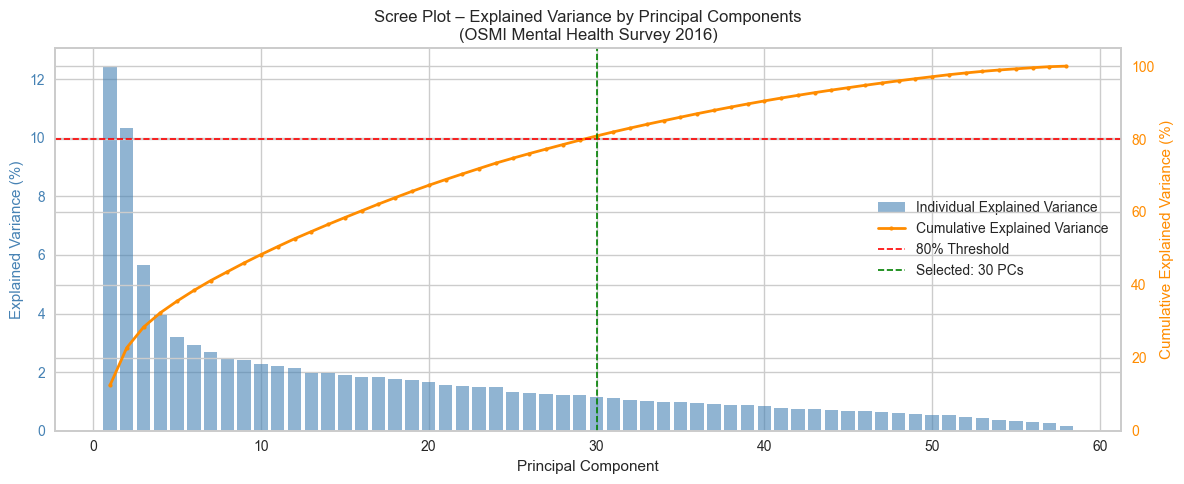

Components selected: 30
Cumulative variance explained: 80.84%


In [15]:
#Step 9 - Eigen Decomposition of the Covariance Matrix
#The Variance-Covariance matrix helps us to understand how different features moves together
#It is also used by PCA to find the axis of the maximum variance
# calculate the variance-covariance matrix
cov_X_std = np.cov(df_standard.T)


#compute eigenvectors and eigenvalues
#The decomposition of the vectors into its eigen vectors and eigen
#values is called matrix eigen decomposition and is computed from the covariance matrix
#The eigen vector with maximum eigen value represents the axis with the maximum variance

eig_vals, eig_vecs = np.linalg.eigh(cov_X_std)

#eigh returns smallest to largest, so reverse it
eig_vals = eig_vals[::-1]
eig_vecs = eig_vecs[:, ::-1]

# present the explained variance as percentages
exp_var = eig_vals/sum(eig_vals) * 100

#compute and print the explained cumulative variance 
cum_exp_var = np.cumsum(exp_var)

print("Cumulative Variance :\n", cum_exp_var)   

# Plotting Scree Plot - 
# A Scree Plot is used for visualizing how much variance each principal component explains
# and to determine the optimal number of Principal Components.

# Number of components
n_components = len(exp_var)
components = np.arange(1, n_components + 1)

# Plotting 
fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart: individual variance per component
ax1.bar(components, exp_var, alpha=0.6, color='steelblue', label='Individual Explained Variance')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart: cumulative variance
ax2 = ax1.twinx()
ax2.plot(components, cum_exp_var, color='darkorange', marker='o', markersize=3, linewidth=2, label='Cumulative Explained Variance')
ax2.axhline(y=80, color='red', linestyle='--', linewidth=1.2, label='80% Threshold')
ax2.set_ylabel('Cumulative Explained Variance (%)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')
ax2.set_ylim([0, 105])

# Marking the selected number of components
selected_n = 30
ax2.axvline(x=selected_n, color='green', linestyle='--', linewidth=1.2, label=f'Selected: {selected_n} PCs')

#Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')

plt.title('Scree Plot – Explained Variance by Principal Components\n(OSMI Mental Health Survey 2016)')
plt.tight_layout()
plt.savefig('scree_plot.png', dpi=300)
plt.show()

#Print summary
print(f"Components selected: {selected_n}")
print(f"Cumulative variance explained: {cum_exp_var[selected_n - 1]:.2f}%")


### Step 10 - Dimensionality Reduction using Princpal Component Axis (30 Principal Components)

In [17]:
#Step 10 - Dimensionality Reduction using PCA
#From the output of the cumultive variance it is evident that the first 30 principal components
#explains 80% of the data 
print("Features before", df_standard.shape[1])

# Keep 30 components (80% variance)
pca = PCA(n_components=30)

df_pca = pca.fit_transform(df_standard) # Projecting the scaled data (58 features) into 30 components 

print("Features after", df_pca.shape[1])

Features before 58
Features after 30


### Step 11 - K-Means Clustering

k=2, silhouette=0.115
k=3, silhouette=0.103
k=4, silhouette=0.083
k=5, silhouette=0.074
k=6, silhouette=0.075
k=7, silhouette=0.082


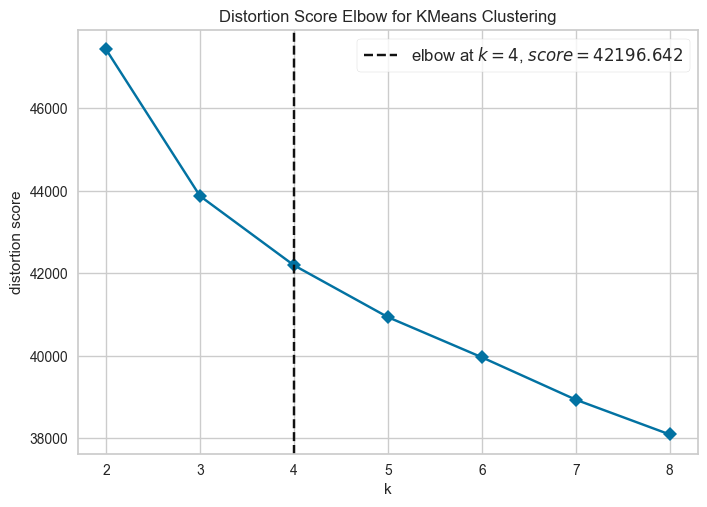

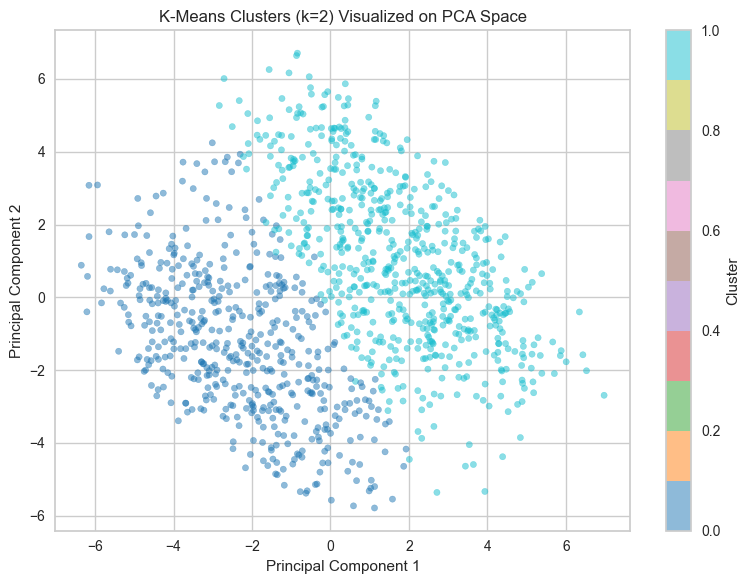

In [ ]:
#conduct a k-Means clustering

# Calculating the silhoutte score for K-means cluster using k values from 2-7 so that we can
# select the best k which truly represents the cluster seperation
for i in range(2, 8):
    km = KMeans(n_clusters=i, random_state=0, n_init=10)
    km.fit(df_pca)                            # Conducting K-Means Clustering
    labels = km.labels_                       # Label Extraction
    score = silhouette_score(df_pca, labels)  # Calculating the Silhouette Score for i number of clusters
    print(f"k={i}, silhouette={score:.3f}")   # Printing the Silhouette Score

#Output -
#k=2, silhouette=0.115
#k=3, silhouette=0.103
#k=4, silhouette=0.083
#k=5, silhouette=0.074
#k=6, silhouette=0.075
#k=7, silhouette=0.082


#checking with elbow method for reference

model = KMeans(random_state=0, n_init=10)

#Using Elbow-Visualizer to calculate the Elbow Score
visualizer = KElbowVisualizer(model, k=(2, 9), timings=False)
visualizer.fit(df_pca)
visualizer.show()

#print("Recommended k  :", visualizer.elbow_value_) 
# #Output - Recommended :4


#The elbow method suggested k=4 but I'm preferring the Silhouette score as it
#considers both the cohesion and the separability of the different clusters and the elbow 
#curve is showing a very gradual decrease.

# Based on the Highest Silhouette Score of 0.115, k=2(clusters) are selected 
km = KMeans(n_clusters=2, random_state=0, n_init=10)
df_cluster = df_encoded.copy()
df_cluster['cluster'] = km.fit_predict(df_pca)


# Visualize clusters on PC1 vs PC2
plt.figure(figsize=(8, 6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=df_cluster['cluster'], cmap='tab10', alpha=0.5, s=20)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clusters (k=2) Visualized on PCA Space')
plt.colorbar(label='Cluster')
plt.tight_layout()
plt.savefig('clusters.png', dpi=150)
plt.show()

### Step 12 Cluster Profiling

In [26]:
# Profile the clusters using the original (pre-scaled) encoded df
cluster_profile = df_cluster.groupby('cluster').mean(numeric_only=True)
print(cluster_profile.T)

cluster                                                     0          1
How many employees does your company or organiz...   2.619238   2.829985
Is your employer primarily a tech company/organ...   0.771543   0.769706
If a mental health issue prompted you to reques...   3.190381   2.573416
How willing would you be to share with friends ...   2.847695   2.661515
Have you ever sought treatment for a mental hea...   0.146293   0.902628
If you have a mental health issue, do you feel ...   0.388778   2.251932
If you have a mental health issue, do you feel ...   0.761523   3.500773
What is your age?                                   33.565130  33.724884
Do you work remotely?                                0.907816   0.914992
Does your employer provide mental health benefi...   0.310621   0.217929
Does your employer provide mental health benefi...   0.336673   0.561051
Do you know the options for mental health care ...   0.553106   0.326121
Do you know the options for mental health care ... 

### Step 13 : Visualizing the Cluster Profiling

['Have you been diagnosed with a mental health condition by a medical professional?_Yes', 'If you have a mental health issue, do you feel that it interferes with your work when NOT being treated effectively?', 'Have you had a mental health disorder in the past?_Yes', 'Have you ever sought treatment for a mental health issue from a mental health professional?', 'Have you had a mental health disorder in the past?_No', 'If you have a mental health issue, do you feel that it interferes with your work when being treated effectively?']


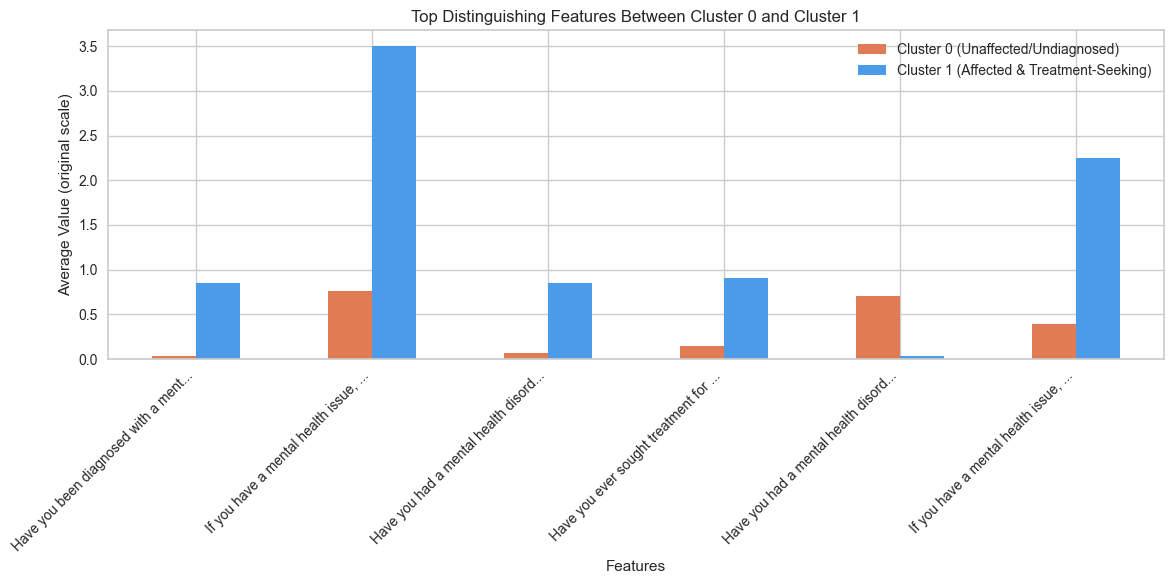

cluster                                                    0         1
Do you think that discussing a mental health di...  0.118236  0.250386
Would you feel comfortable discussing a mental ...  0.332665  0.349304
Would you feel comfortable discussing a mental ...  0.260521  0.318393
Do you feel that being identified as a person w...  0.378758  0.523957
Do you think that team members/co-workers would...  0.236473  0.340031
Would you bring up a mental health issue with a...  0.511022  0.720247
Have you heard of or observed negative conseque...  0.052104  0.111283


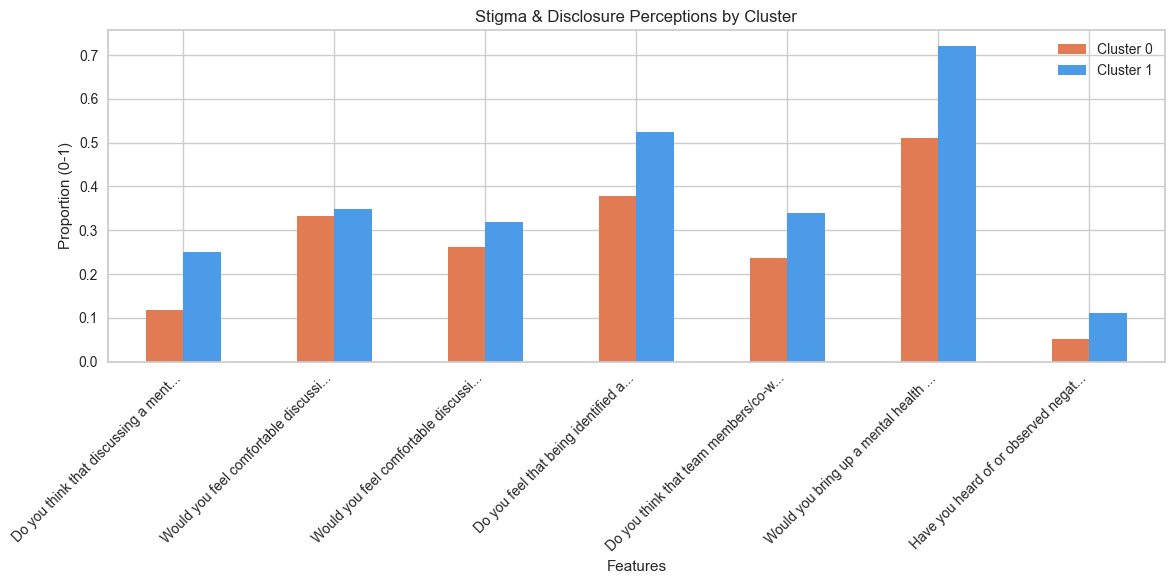

In [29]:
# Add cluster labels to scaled data (for ranking only)
df_standard_cluster = df_standard.copy()
df_standard_cluster['cluster'] = df_cluster['cluster'].values

cluster_profile = df_cluster.groupby('cluster').mean(numeric_only=True)          # original values, for the display using standardized values
scaled_profile  = df_standard_cluster.groupby('cluster').mean(numeric_only=True) # scaled values, for ranking

# Step 1: Get top 6 most different features (ranked on SCALED data)
top_cols = scaled_profile.T.copy()
top_cols['diff'] = abs(top_cols[0] - top_cols[1])
top_features = top_cols.sort_values('diff', ascending=False).head(6).index.tolist()
print(top_features)

# Step 2: Prepare plot data (using ORIGINAL values for interpretability)
plot_data = cluster_profile[top_features].T
plot_data.columns = ['Cluster 0 (Unaffected/Undiagnosed)', 
                     'Cluster 1 (Affected & Treatment-Seeking)']

# Step 3: Shorten long column names for display
plot_data.index = [col[:35] + '...' if len(col) > 35 else col 
                   for col in plot_data.index]

# Step 4: Plot
plot_data.plot(kind='bar', figsize=(12, 6), color=['#E07B54', '#4C9BE8'])
plt.title('Top Distinguishing Features Between Cluster 0 and Cluster 1')
plt.ylabel('Average Value (original scale)')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

stigma_cols = [
    'Do you think that discussing a mental health disorder with your employer would have negative consequences?_Yes',
    'Would you feel comfortable discussing a mental health disorder with your coworkers?_No',
    'Would you feel comfortable discussing a mental health disorder with your direct supervisor(s)?_No',
    'Do you feel that being identified as a person with a mental health issue would hurt your career?_Yes',
    'Do you think that team members/co-workers would view you more negatively if they knew you suffered from a mental health issue?_Yes',
    'Would you bring up a mental health issue with a potential employer in an interview?_No',
    'Have you heard of or observed negative consequences for co-workers who have been open about mental health issues in your workplace?_Yes',
]

#Stigma
stigma_profile = df_cluster.groupby('cluster')[stigma_cols].mean()
print(stigma_profile.T)

# Prepare plot data
plot_data_stigma = stigma_profile.T.copy()
plot_data_stigma.columns = ['Cluster 0', 'Cluster 1']

# Shorten long labels for display
plot_data_stigma.index = [col[:35] + '...' if len(col) > 35 else col 
                           for col in plot_data_stigma.index]

# Plot
plot_data_stigma.plot(kind='bar', figsize=(12, 6), color=['#E07B54', '#4C9BE8'])
plt.title('Stigma & Disclosure Perceptions by Cluster')
plt.ylabel('Proportion (0-1)')
plt.xlabel('Features')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()